In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("CarPrice_Assignment.csv")

In [3]:
#datacleaning
np.random.seed(42)
df.loc[df.sample(frac=0.05).index, 'enginesize'] = np.nan

median_engine = df['enginesize'].median()
df['enginesize'] = df['enginesize'].fillna(median_engine)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    float64
 1

In [5]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.546341,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,40.882232,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
#Feature Engineering
X_raw = df[['enginesize', 'horsepower', 'carbody']]
Y = df['price']

X_encoded = pd.get_dummies(X_raw, columns=['carbody'], drop_first=True, dtype=int)

In [7]:
#Data Split & Feature Scaling
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#Model Training & Evaluation
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

Y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print(f"RMSE: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

RMSE: $4795.40
R2 Score: 0.7087


In [9]:
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Weight': model.coef_
})
print(importance.sort_values(by='Weight', key=abs, ascending=False).to_string(index=False))

          Feature       Weight
       enginesize  4093.211894
       horsepower  2819.486296
carbody_hatchback -2457.155259
    carbody_sedan -1424.428315
    carbody_wagon -1282.952634
  carbody_hardtop  -344.602680


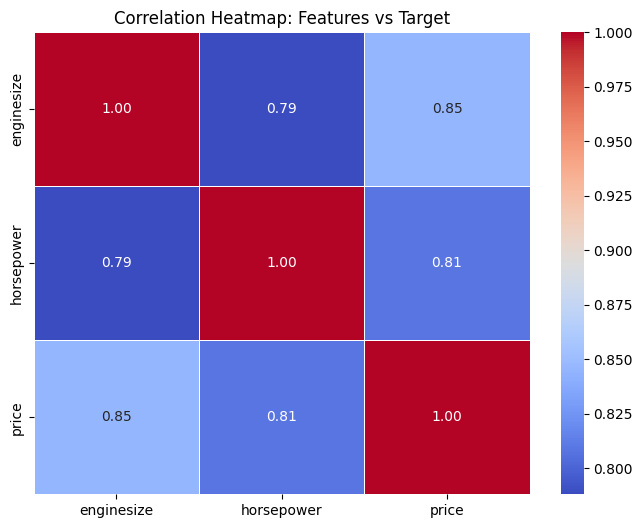

In [10]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
corr_matrix = df[['enginesize', 'horsepower', 'price']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Features vs Target")
plt.show()

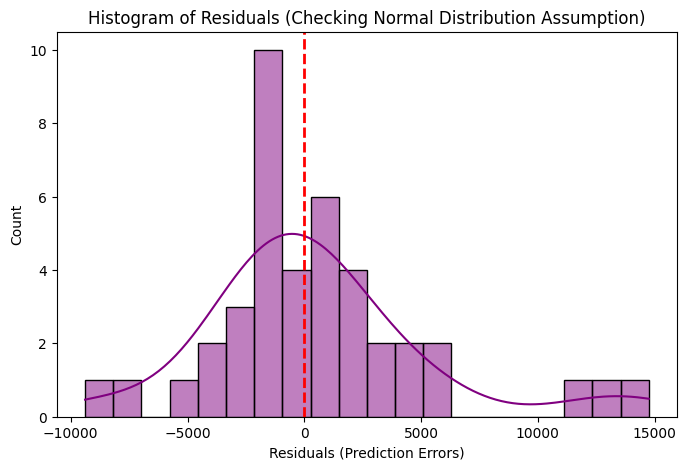

In [11]:
# Distribution Histogram of Target Errors
Y_pred_standard = model.predict(X_test_scaled)
residuals = Y_test - Y_pred_standard

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="purple", bins=20)
plt.axvline(x=0, color="red", linestyle="--", lw=2)
plt.xlabel("Residuals (Prediction Errors)")
plt.ylabel("Count")
plt.title("Histogram of Residuals (Checking Normal Distribution Assumption)")
plt.show()

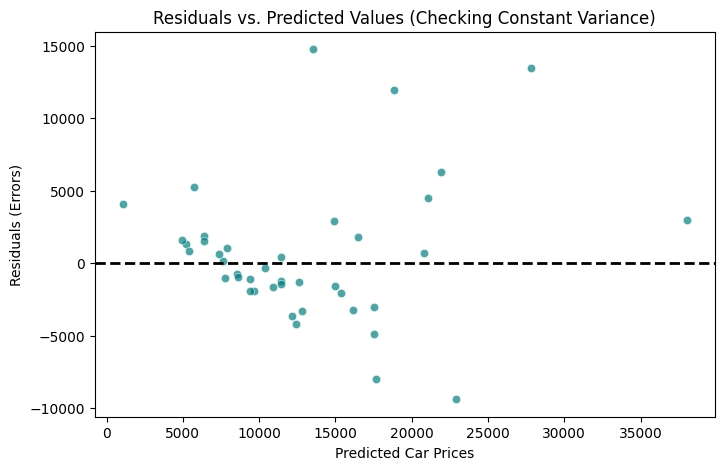

In [12]:
# Homoscedasticity Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y_pred_standard, y=residuals, alpha=0.7, color="teal")
plt.axhline(y=0, color="black", linestyle="--", lw=2)
plt.xlabel("Predicted Car Prices")
plt.ylabel("Residuals (Errors)")
plt.title("Residuals vs. Predicted Values (Checking Constant Variance)")
plt.show()

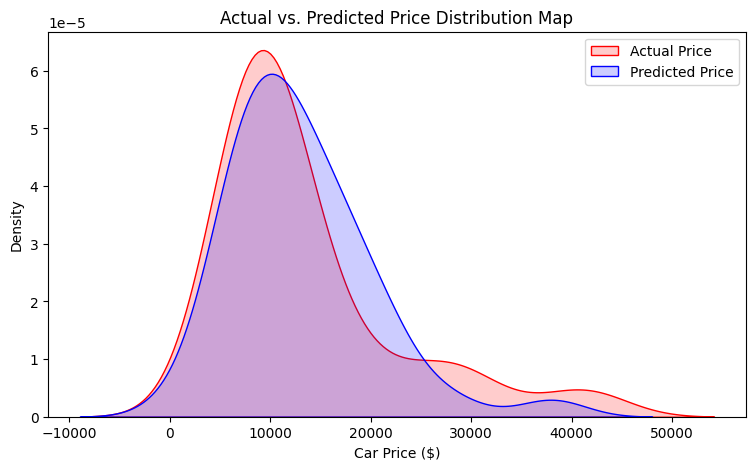

In [13]:
# Actual vs. Predicted Prices Comparison Map
plt.figure(figsize=(9, 5))
sns.kdeplot(Y_test, color="red", label="Actual Price", fill=True, alpha=0.2)
sns.kdeplot(Y_pred_standard, color="blue", label="Predicted Price", fill=True, alpha=0.2)
plt.xlabel("Car Price ($)")
plt.ylabel("Density")
plt.title("Actual vs. Predicted Price Distribution Map")
plt.legend()
plt.show()

In [16]:
#Actual vs. Predicted Comparison Table
comparison_df = pd.DataFrame({
    'Actual Price': Y_test.values,
    'Predicted Price': Y_pred_standard
})

comparison_df['Absolute Error'] = (comparison_df['Actual Price'] - comparison_df['Predicted Price']).abs()

comparison_df = comparison_df.round(2)

comparison_df.head(10)

,Actual Price,Predicted Price,Absolute Error
0,30760.00,18806.08,11953.92
1,17859.17,14930.00,2929.16
2,9549.00,12830.39,3281.39
3,11850.00,11414.89,435.11
4,28248.00,13501.89,14746.11
5,7799.00,8532.50,733.50
6,7788.00,7618.57,169.43
7,9258.00,10932.23,1674.23
8,10198.00,11463.13,1265.13
9,7775.00,9666.79,1891.79
